# AMR（省份×年份）固定效应主流程（双固定效应版）

本 notebook 以原 `amr_lancet_fe_from_raw_csv.ipynb` 为主文件，并合并了原 `fixed_effects_model.ipynb` 中仍需保留的输出逻辑，包括 `FE_OUTPUT` 简化结果表和系数图。

- 原始设计：Province FE + Year FE（双固定效应）
- 当前设定：Province FE + Year FE + 省份聚类稳健 SE
- Baseline 和 Lag-1 使用相同的固定效应设定
- 导出文件带 `_both` 后缀，避免覆盖其他版本结果


In [1]:
# =========================
# 0) Imports & settings
# =========================
import os
import math
import itertools
import warnings

import numpy as np
import pandas as pd

from linearmodels.panel import PanelOLS
import statsmodels.api as sm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)


## 1) 读取数据 + 统一主键列名（Province / Year）

这段基本就是你截图里那套逻辑：
- `normalize_key_cols()` 把“省份/Province/prov”等归一为 `Province`
- 把“Year/yr/年份”等归一为 `Year`
- 省份去空格、Year 转数值
- 只保留 2014–2023



In [2]:
# =========================
# 1) Read raw CSVs
# =========================
amr_path = r"C:\Users\lunch\Downloads\amr_rate.csv"
x_path   = r"C:\Users\lunch\Downloads\climate_social_eco.csv"

amr = pd.read_csv(amr_path, encoding="utf-8-sig")
x   = pd.read_csv(x_path,   encoding="utf-8-sig")

def normalize_key_cols(df: pd.DataFrame) -> pd.DataFrame:
    col_map = {}
    for c in df.columns:
        cc = str(c).strip()
        ccl = cc.lower()
        if ccl in ["province", "prov", "省份"]:
            col_map[c] = "Province"
        if ccl in ["year", "yr", "年份", "year "]:
            col_map[c] = "Year"
    return df.rename(columns=col_map)

amr = normalize_key_cols(amr)
x   = normalize_key_cols(x)

assert "Province" in amr.columns and "Year" in amr.columns, "AMR表缺 Province/Year"
assert "Province" in x.columns   and "Year" in x.columns,   "X表缺 Province/Year"

amr["Province"] = amr["Province"].astype(str).str.strip()
x["Province"]   = x["Province"].astype(str).str.strip()

amr["Year"] = pd.to_numeric(amr["Year"], errors="coerce").astype("Int64")
x["Year"]   = pd.to_numeric(x["Year"],   errors="coerce").astype("Int64")

# 只保留 2014–2023
amr = amr[amr["Year"].between(2014, 2023)]
x   = x[x["Year"].between(2014, 2023)]

print("AMR shape:", amr.shape, "X shape:", x.shape)
print("Unique keys (AMR):", amr[["Province","Year"]].dropna().drop_duplicates().shape)
print("Unique keys (X)  :", x[["Province","Year"]].dropna().drop_duplicates().shape)

amr.head()


AMR shape: (313, 15) X shape: (310, 31)
Unique keys (AMR): (313, 2)
Unique keys (X)  : (310, 2)


,Province,Year,MRCNS,VREFS,VREFM,PRSP,ERSP,3GCRKP,MRSA,3GCREC,CREC,QREC,CRPA,CRKP,CRAB
0,北京,2014,82.2,1.6,11.1,0.4,97.0,39.0,49.0,58.8,3.6,61.3,36.1,13.7,64.0
1,天津,2014,79.6,0.3,1.9,9.3,96.2,21.5,24.8,51.4,1.5,51.0,22.1,1.7,22.1
2,河北,2014,80.3,0.7,2.4,7.0,97.4,47.5,43.4,66.3,2.2,60.1,30.9,6.7,63.0
3,山西,2014,70.5,0.6,1.3,1.4,93.8,31.7,24.2,58.4,1.2,55.5,20.4,2.6,52.7
4,内蒙古,2014,76.3,0.7,1.4,9.1,95.8,26.1,28.9,55.6,0.6,65.4,20.2,1.9,51.5


## 2) 选择你截图中的 9 个 X（支持列名映射）

你截图里是这种映射：

- TA → 省平均气温  
- PA → 省平均降水  
- R1xday → R1xday  
- PM25 → PM2.5  
- MED → 医疗水平  
- GDP → GDP  
- WATER → 城市用水普及率  
- WASTE → 生活垃圾无害化处理率  
- AMC → 抗菌药物使用强度  

下面代码会：
1) 如果 X 表里是 `TA/PA/PM25/...` 这类列名，会自动 rename 成中文列名；  
2) 如果你 X 表里本来就已经是中文列名，也能直接用；  
3) 最终确保 `X_cols_used` 一定是你截图那 9 个中文列名。



In [3]:
# =========================
# 2) Select X cols (with robust mapping)
# =========================
X_MAP = {
    "TA": "省平均气温",
    "PA": "省平均降水",
    "R1xday": "R1xday",
    "PM25": "PM2.5",
    "MED": "医疗水平",
    "GDP": "GDP",
    "WATER": "城市用水普及率",
    "WASTE": "生活垃圾无害化处理率",
    "AMC": "抗菌药物使用强度",
}

# 先做一次“如果存在英文缩写列名，就 rename 成中文列名”
rename_map = {k: v for k, v in X_MAP.items() if k in x.columns and v not in x.columns}
x = x.rename(columns=rename_map)

# 目标：最终使用这 9 个中文列名
X_cols_used = list(X_MAP.values())

missing_x = [c for c in X_cols_used if c not in x.columns]
if missing_x:
    raise KeyError(f"X表缺少这些列（按截图要求）：{missing_x}\n当前x.columns示例：{list(x.columns)[:30]}")

print("Selected X mapping:")
for k, v in X_MAP.items():
    print(f"{k:6s} -> {v}")

print("\nX_cols used:", X_cols_used)

x[X_cols_used].head()


Selected X mapping:
TA     -> 省平均气温
PA     -> 省平均降水
R1xday -> R1xday
PM25   -> PM2.5
MED    -> 医疗水平
GDP    -> GDP
WATER  -> 城市用水普及率
WASTE  -> 生活垃圾无害化处理率
AMC    -> 抗菌药物使用强度

X_cols used: ['省平均气温', '省平均降水', 'R1xday', 'PM2.5', '医疗水平', 'GDP', '城市用水普及率', '生活垃圾无害化处理率', '抗菌药物使用强度']


,省平均气温,省平均降水,R1xday,PM2.5,医疗水平,GDP,城市用水普及率,生活垃圾无害化处理率,抗菌药物使用强度
0,11.802834,459.925228,39.409802,5.74,99,23577.5,100.00,99.6,NaN
1,13.439358,445.971354,33.522428,13.95,56,10749.2,100.00,96.7,NaN
2,10.775661,439.600300,22.180385,179.77,48,25644.1,99.29,86.6,NaN
3,9.330009,533.038397,26.461773,150.68,57,12307.0,98.54,92.1,NaN
4,4.819860,286.822913,10.227644,102.15,62,12377.3,97.79,96.1,NaN


## 3) 合并面板（Province-Year）

按你截图：`how="inner"`。  
并且输出合并后面板的 shape / 年份范围 / 省份数量。

> 你现在的预期是：Merged = (310, 44) / Years 2014–2023 / Provinces 31

另外补一个常见坑：如果 `amr` 或 `x` 存在重复 `Province-Year`，会导致 merge 后行数异常。这里提供两种策略：
- 默认：直接 `drop_duplicates(Province,Year)`（保留第一条）
- 可改：按同一省同一年对数值列取均值（更稳）



In [4]:
# =========================
# 3) Merge panel (Province-Year)
# =========================
DEDUP_STRATEGY = "drop"   # "drop" or "mean"

def dedup_panel(df: pd.DataFrame, key=("Province","Year"), strategy="drop") -> pd.DataFrame:
    if strategy == "drop":
        return df.drop_duplicates(list(key), keep="first").copy()
    if strategy == "mean":
        # key 以外的数值列取均值，非数值列取第一条
        num_cols = [c for c in df.columns if c not in key and pd.api.types.is_numeric_dtype(df[c])]
        other_cols = [c for c in df.columns if c not in key and c not in num_cols]
        g = df.groupby(list(key), as_index=False)
        out = g[num_cols].mean()
        for c in other_cols:
            out[c] = g[c].first()[c].values
        return out
    raise ValueError("strategy must be 'drop' or 'mean'")

# 与 fixed_effects_model.ipynb 对齐：这里直接按 Province-Year 做 inner merge
df = amr.merge(x, on=["Province","Year"], how="inner", suffixes=("", "_X"))
df = df.dropna(subset=["Province","Year"]).copy()
df["Year"] = df["Year"].astype(int)

print("Merged:", df.shape)
print("Years:", df["Year"].min(), df["Year"].max())
print("Provinces:", df["Province"].nunique())
df.head()


Merged: (310, 44)
Years: 2014 2023
Provinces: 31


,Province,Year,MRCNS,VREFS,VREFM,PRSP,ERSP,3GCRKP,MRSA,3GCREC,CREC,QREC,CRPA,CRKP,CRAB,主要城市平均气温,主要城市降水量,主要城市日照时数,省平均气温,省平均降水,TA（°C）,PA（%）,R1xday,R5xday,二氧化硫,氮氧化物,PM2.5,可支配收入,食品消费量,文盲比例,GDP,建成区绿化覆盖率,医疗水平,生活垃圾无害化处理率,卫生程度\n（日污水处理能力）,城市用水普及率,饮用水\n供水综合生产能力(万立方米/日),人均日生活用水量(升),牲畜饲养\n-大牲畜年底头数,牲畜饲养\n-猪年底头数,牲畜饲养\n-羊年底头数,抗菌药物使用强度,Unnamed: 29,Unnamed: 30
0,北京,2014,82.2,1.6,11.1,0.4,97.0,39.0,49.0,58.8,3.6,61.3,36.1,13.7,64.0,14.1,461.5,2344.1,11.802834,459.925228,0.649418,-8.840281,39.409802,68.626410,7.89,15.10,5.74,44489,NaN,1.48,23577.5,49.1,99,99.6,442.0,100.00,2439.77,187.52,20.32,179.60,68.35,NaN,NaN,NaN
1,天津,2014,79.6,0.3,1.9,9.3,96.2,21.5,24.8,51.4,1.5,51.0,22.1,1.7,22.1,14.0,441.4,2265.6,13.439358,445.971354,0.668522,-12.685535,33.522428,64.648231,20.92,28.23,13.95,28832,NaN,2.35,10749.2,34.9,56,96.7,262.6,100.00,447.15,124.33,30.38,199.78,46.76,NaN,NaN,NaN
2,河北,2014,80.3,0.7,2.4,7.0,97.4,47.5,43.4,66.3,2.2,60.1,30.9,6.7,63.0,14.9,294.8,1585.4,10.775661,439.600300,0.622596,-7.823015,22.180385,39.758130,118.99,151.25,179.77,16647,NaN,3.14,25644.1,41.9,48,86.6,523.2,99.29,809.04,116.91,488.23,1915.45,1526.40,NaN,NaN,NaN
3,山西,2014,70.5,0.6,1.3,1.4,93.8,31.7,24.2,58.4,1.2,55.5,20.4,2.6,52.7,10.9,428.7,2513.5,9.330009,533.038397,0.350352,6.659371,26.461773,54.392163,120.82,106.99,150.68,16538,NaN,2.89,12307.0,40.1,57,92.1,208.5,98.54,453.65,114.59,123.87,514.74,922.74,NaN,NaN,NaN
4,内蒙古,2014,76.3,0.7,1.4,9.1,95.8,26.1,28.9,55.6,0.6,65.4,20.2,1.9,51.5,7.7,394.8,2517.2,4.819860,286.822913,0.530587,-1.619586,10.227644,23.507594,131.24,125.83,102.15,20559,NaN,4.66,12377.3,39.8,62,96.1,189.5,97.79,425.47,103.49,839.86,669.44,5569.28,NaN,NaN,NaN


## 4) 固定 13 个 AMR + X 缺失处理 + 构造 `AMR_AGG_z`（沿用原 `fixed_effects_model.ipynb` 口径）

In [5]:
# =========================
# 4) Align processing with fixed_effects_model.ipynb
# =========================
def to_float(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce").astype(float)

def zscore_series(s: pd.Series) -> pd.Series:
    s = to_float(s)
    mu = np.nanmean(s.values)
    sd = np.nanstd(s.values, ddof=0)
    if not np.isfinite(sd) or sd == 0:
        return s * 0.0
    return (s - mu) / sd

def zscore_x(s: pd.Series) -> pd.Series:
    s = to_float(s)
    mu = np.nanmean(s.values)
    sd = np.nanstd(s.values, ddof=0)
    if not np.isfinite(sd) or sd == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mu) / sd

AMR_COLS = [c for c in df.columns if c in [
    "MRCNS","VREFS","VREFM","PRSP","ERSP","3GCRKP","MRSA","3GCREC","CREC","QREC","CRPA","CRKP","CRAB"
]]
print("AMR cols found:", AMR_COLS)

# 转数值
for c in X_cols_used + AMR_COLS:
    df[c] = to_float(df[c])

# X 的缺失值处理：先按省份中位数填补，再用全局中位数兜底
for c in X_cols_used:
    df[c] = df.groupby("Province")[c].transform(lambda s: s.fillna(s.median()))
    df[c] = df[c].fillna(df[c].median())

if "AMR_AGG" not in df.columns:
    df["AMR_AGG"] = df[AMR_COLS].mean(axis=1, skipna=True)

if "AMR_AGG_z" not in df.columns:
    Z = pd.DataFrame({c: zscore_series(df[c]) for c in AMR_COLS})
    df["AMR_AGG_z"] = Z.mean(axis=1, skipna=True)
    print("Created AMR_AGG_z aligned with fixed_effects_model.ipynb")
else:
    df["AMR_AGG_z"] = to_float(df["AMR_AGG_z"])

df[["AMR_AGG","AMR_AGG_z"]].describe()


AMR cols found: ['MRCNS', 'VREFS', 'VREFM', 'PRSP', 'ERSP', '3GCRKP', 'MRSA', '3GCREC', 'CREC', 'QREC', 'CRPA', 'CRKP', 'CRAB']
Created AMR_AGG_z aligned with fixed_effects_model.ipynb


,AMR_AGG,AMR_AGG_z
count,307.000000,307.000000
mean,32.633110,-0.000093
std,3.519738,0.592088
min,24.753846,-1.375048
25%,30.296154,-0.384427
50%,31.930769,-0.139798
75%,34.546154,0.353142
max,42.453846,1.676874


## 5) 主固定效应模型（当前：Province FE + Year FE + 省份聚类稳健 SE）

In [6]:
# =========================
# 5) Fixed-effects regression (Two-way FE)
# =========================
Y_COL = "AMR_AGG_z"      # <-- 可改为某个单项 AMR
X_COLS = X_cols_used     # 当前主模型使用的中文变量名
MODEL_TAG = "both"
MODEL_LABEL = "Two-way FE"

# X 全部 z-score（与固定主线保持一致，便于比较标准化系数）
for c in X_COLS:
    df[c] = zscore_x(df[c])

# panel index
d = df.set_index(["Province","Year"]).sort_index()

Y = to_float(d[Y_COL])
X = d[X_COLS].copy()

# drop missing
tmp = pd.concat([Y, X], axis=1).dropna()
Y = tmp[Y_COL]
X = tmp[X_COLS]

ENTITY_EFFECTS = True
TIME_EFFECTS = True

# 通过这两个开关控制是否纳入省份/年份固定效应
mod = PanelOLS(Y, X, entity_effects=ENTITY_EFFECTS, time_effects=TIME_EFFECTS)
res = mod.fit(cov_type="clustered", cluster_entity=True)

print(res.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:              AMR_AGG_z   R-squared:                        0.0293
Estimator:                   PanelOLS   R-squared (Between):             -0.5202
No. Observations:                 307   R-squared (Within):              -0.6293
Date:                Fri, Apr 17 2026   R-squared (Overall):             -0.5293
Time:                        02:37:06   Log-likelihood                    104.11
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.8646
Entities:                          31   P-value                           0.5575
Avg Obs:                       9.9032   Distribution:                   F(9,258)
Min Obs:                       7.0000                                           
Max Obs:                      10.0000   F-statistic (robust):             0.9907
                            

## 6) 生成 Lancet 风格 Table（Coefficient / 95%CI / p value + FE=Yes + R² + N）



In [7]:
# =========================
# 6) Build Lancet-style table
# =========================
def p_to_text(p: float) -> str:
    if not np.isfinite(p):
        return ""
    if p < 1e-4:
        return "<0.0001"
    return f"{p:.4f}".rstrip("0").rstrip(".")

def p_to_stars(p: float) -> str:
    if not np.isfinite(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

def fmt_coef(x: float, digits=4, stars="") -> str:
    if not np.isfinite(x):
        return ""
    return f"{x:.{digits}f}".rstrip("0").rstrip(".") + stars

def fmt_ci(lo: float, hi: float, digits=4) -> str:
    if not (np.isfinite(lo) and np.isfinite(hi)):
        return ""
    return f"{fmt_coef(lo,digits)}–{fmt_coef(hi,digits)}"

def build_lancet_table(res, X_COLS_use, dominance_map_text=None, coef_digits=4, r2_digits=2, entity_effects=False, time_effects=True):
    """
    res: linearmodels.panel.results.PanelEffectsResults (PanelOLS fit result)
    X_COLS_use: list of predictor names exactly as in res.params index
    dominance_map_text: optional dict {predictor: "xx% (lo–hi)"} or None
    """
    ci = res.conf_int()
    ci_lo = ci.iloc[:, 0]
    ci_hi = ci.iloc[:, 1]
    
    rows = []
    for xname in X_COLS_use:
        b  = float(res.params.get(xname, np.nan))
        p  = float(res.pvalues.get(xname, np.nan))
        lo = float(ci_lo.loc[xname]) if xname in ci_lo.index else np.nan
        hi = float(ci_hi.loc[xname]) if xname in ci_hi.index else np.nan

        dom_txt = ""
        if dominance_map_text is not None and xname in dominance_map_text:
            dom_txt = dominance_map_text[xname]

        st = p_to_stars(p)

        rows.append({
            "Predictor": xname,
            "Coefficient": fmt_coef(b, coef_digits, st),
            "95% CI": fmt_ci(lo, hi, coef_digits),
            "p value": p_to_text(p),
            "Dominance (95% CI)": dom_txt
        })

    # FE indicators
    rows.append({"Predictor": "Province", "Coefficient": "Yes" if entity_effects else "No", "95% CI": "", "p value": "", "Dominance (95% CI)": ""})
    rows.append({"Predictor": "Year",     "Coefficient": "Yes" if time_effects else "No", "95% CI": "", "p value": "", "Dominance (95% CI)": ""})

    tab = pd.DataFrame(rows)

    # Model stats
    tab_stats = pd.DataFrame([
        {"Predictor": "R² (within)", "Coefficient": fmt_coef(float(res.rsquared_within), r2_digits),
         "95% CI": "", "p value": "", "Dominance (95% CI)": ""},
        {"Predictor": "Total number of observations", "Coefficient": str(int(res.nobs)),
         "95% CI": "", "p value": "", "Dominance (95% CI)": ""},
    ])

    tab_full = pd.concat([tab, tab_stats], ignore_index=True)
    return tab_full

def to_lancet_display_table(tab: pd.DataFrame) -> pd.DataFrame:
    out = tab[["Predictor", "Coefficient", "Dominance (95% CI)", "p value"]].copy()
    summary_mask = out["Predictor"].isin(["R² (within)", "Total number of observations"])
    out.loc[summary_mask, "Dominance (95% CI)"] = ".."
    out.loc[summary_mask, "p value"] = ".."
    return out

X_COLS = list(res.params.index)

# 2) 如果你不做 dominance（通常 lag 模型不做），直接生成：
tab_full = build_lancet_table(
    res, X_COLS, dominance_map_text=None,
    entity_effects=ENTITY_EFFECTS, time_effects=TIME_EFFECTS
)

tab_lancet = to_lancet_display_table(tab_full)

tab_lancet


,Predictor,Coefficient,Dominance (95% CI),p value
0,省平均气温,0.6122,,0.4204
1,省平均降水,-0.0451,,0.5092
2,R1xday,-0.0024,,0.8986
3,PM2.5,-0.0039,,0.9222
4,医疗水平,0.1354,,0.1315
5,GDP,0.0049,,0.9663
6,城市用水普及率,0.0062,,0.7704
7,生活垃圾无害化处理率,-0.0013,,0.9496
8,抗菌药物使用强度,0.0094,,0.4591
9,Province,Yes,,


## 7) （可选）Dominance（95% CI）——Shapley R² 分解 + 省份 cluster bootstrap

如果你想严格复刻 Lancet 表格的 “Dominance (95% CI)” 这一列，可以打开本节：

- 在两维去均值（within）后的空间里，对解释度 R² 做 Shapley 分解 → 每个 X 的贡献占比（%）
- 省份 cluster bootstrap 得到 95% CI

> 注意：解释变量越多，Shapley 计算越慢（复杂度 ~ 2^k）。9 个变量没问题。



In [8]:
# =========================
# 7) Dominance (optional)
# =========================
# RUN_DOMINANCE = False
RUN_DOMINANCE = True
N_BOOT = 200  # 论文级别可以 500+

def twoway_demean(panel_series: pd.Series) -> pd.Series:
    ent = panel_series.groupby(level=0).transform("mean")
    tim = panel_series.groupby(level=1).transform("mean")
    grand = panel_series.mean()
    return panel_series - ent - tim + grand

def ols_r2(y: np.ndarray, X: np.ndarray) -> float:
    if X.size == 0:
        yhat = np.full_like(y, y.mean())
    else:
        X_ = sm.add_constant(X, has_constant="add")
        b = np.linalg.lstsq(X_, y, rcond=None)[0]
        yhat = X_ @ b
    ssr = np.sum((y - yhat)**2)
    sst = np.sum((y - y.mean())**2)
    if sst <= 0:
        return np.nan
    return 1 - ssr/sst

def shapley_r2(y: np.ndarray, X: np.ndarray, names: list[str]) -> pd.Series:
    k = len(names)
    idx = list(range(k))
    r2_cache = {}
    for r in range(k+1):
        for S in itertools.combinations(idx, r):
            if len(S) == 0:
                r2_cache[S] = ols_r2(y, np.empty((len(y), 0)))
            else:
                r2_cache[S] = ols_r2(y, X[:, S])
    phi = np.zeros(k)
    factorial = math.factorial
    for j in idx:
        for r in range(k):
            for S in itertools.combinations([i for i in idx if i != j], r):
                S = tuple(sorted(S))
                Sj = tuple(sorted(S + (j,)))
                w = factorial(r) * factorial(k - r - 1) / factorial(k)
                phi[j] += w * (r2_cache[Sj] - r2_cache[S])
    return pd.Series(phi, index=names)

def dominance_with_ci(panel: pd.DataFrame, ycol: str, xcols: list[str], n_boot=200, seed=123):
    rng = np.random.default_rng(seed)

    y_w = twoway_demean(panel[ycol]).dropna()
    X_w = pd.DataFrame({c: twoway_demean(panel[c]) for c in xcols}).loc[y_w.index].dropna()
    idx = y_w.index.intersection(X_w.index)
    y_w = y_w.loc[idx]
    X_w = X_w.loc[idx]

    y = y_w.values.astype(float)
    X = X_w.values.astype(float)

    phi = shapley_r2(y, X, xcols)
    total_r2 = ols_r2(y, X)
    dom = (phi / total_r2) * 100.0

    provinces = np.array(sorted(set(idx.get_level_values(0))))
    boot_vals = {c: [] for c in xcols}

    for b in range(n_boot):
        samp = rng.choice(provinces, size=len(provinces), replace=True)
        parts = []
        for p in samp:
            parts.append(idx[idx.get_level_values(0) == p])
        boot_idx = parts[0].append(parts[1:]) if len(parts) > 1 else parts[0]

        yb = y_w.loc[boot_idx].values.astype(float)
        Xb = X_w.loc[boot_idx].values.astype(float)

        if np.nanstd(yb) == 0:
            continue
        try:
            phib = shapley_r2(yb, Xb, xcols)
            r2b = ols_r2(yb, Xb)
            domb = (phib / r2b) * 100.0
            for c in xcols:
                boot_vals[c].append(float(domb[c]))
        except Exception:
            continue

    out = []
    for c in xcols:
        arr = np.array(boot_vals[c], dtype=float)
        arr = arr[np.isfinite(arr)]
        lo, hi = (np.nan, np.nan) if arr.size < max(30, n_boot//5) else np.percentile(arr, [2.5, 97.5])
        out.append({
            "Predictor": c,
            "Dominance_pct": float(dom[c]),
            "Dominance_lo": float(lo) if np.isfinite(lo) else np.nan,
            "Dominance_hi": float(hi) if np.isfinite(hi) else np.nan,
            "n_boot_used": int(arr.size),
        })
    return pd.DataFrame(out)

if RUN_DOMINANCE:
    dom_df = dominance_with_ci(d[[Y_COL] + X_COLS], Y_COL, X_COLS, n_boot=N_BOOT, seed=123)
    dom_map = dom_df.set_index("Predictor")

    def dom_text(p):
        v  = dom_map.loc[p, "Dominance_pct"]
        lo = dom_map.loc[p, "Dominance_lo"]
        hi = dom_map.loc[p, "Dominance_hi"]
        if np.isfinite(lo) and np.isfinite(hi):
            return f"{v:.1f}% ({lo:.1f}–{hi:.1f})"
        return f"{v:.1f}%"

    tab_full.loc[tab_full["Predictor"].isin(X_COLS), "Dominance (95% CI)"] = tab_full.loc[tab_full["Predictor"].isin(X_COLS), "Predictor"].map(dom_text)

tab_lancet = to_lancet_display_table(tab_full)

tab_lancet


,Predictor,Coefficient,Dominance (95% CI),p value
0,省平均气温,0.6122,17.4% (0.4–55.1),0.4204
1,省平均降水,-0.0451,6.8% (0.3–30.2),0.5092
2,R1xday,-0.0024,0.5% (0.2–15.7),0.8986
3,PM2.5,-0.0039,0.2% (0.3–39.7),0.9222
4,医疗水平,0.1354,52.2% (0.7–60.8),0.1315
5,GDP,0.0049,2.5% (0.5–41.5),0.9663
6,城市用水普及率,0.0062,16.5% (0.1–38.5),0.7704
7,生活垃圾无害化处理率,-0.0013,0.4% (0.3–40.8),0.9496
8,抗菌药物使用强度,0.0094,3.4% (0.1–22.3),0.4591
9,Province,Yes,,


In [9]:
dom_df


,Predictor,Dominance_pct,Dominance_lo,Dominance_hi,n_boot_used
0,省平均气温,17.388431,0.402083,55.116932,200
1,省平均降水,6.806286,0.293462,30.186227,200
2,R1xday,0.545400,0.167401,15.722177,200
3,PM2.5,0.170307,0.298772,39.683325,200
4,医疗水平,52.227224,0.713185,60.826067,200
5,GDP,2.489146,0.527956,41.527040,200
6,城市用水普及率,16.508965,0.132634,38.474440,200
7,生活垃圾无害化处理率,0.447091,0.279026,40.752168,200
8,抗菌药物使用强度,3.417150,0.106550,22.329394,200


## 8) 导出 Lancet 风格结果表（文件名附模型后缀）

In [10]:
# =========================
# 8) Export baseline Lancet-style table
# =========================
OUT_DIR = "outputs_lancet_fe"
os.makedirs(OUT_DIR, exist_ok=True)

csv_out = os.path.join(OUT_DIR, f"lancet_table_{Y_COL}_{MODEL_TAG}.csv")
xlsx_out = os.path.join(OUT_DIR, f"lancet_table_{Y_COL}_{MODEL_TAG}.xlsx")

tab_lancet.to_csv(csv_out, index=False, encoding="utf-8-sig")
tab_lancet.to_excel(xlsx_out, index=False)

print("Saved:", csv_out)
print("Saved:", xlsx_out)


Saved: outputs_lancet_fe\lancet_table_AMR_AGG_z_both.csv
Saved: outputs_lancet_fe\lancet_table_AMR_AGG_z_both.xlsx


### **滞后一年（沿用与主模型相同的固定效应设定）**

In [11]:
# 对所有变量构造 Lag-1 并跑固定效应（沿用与主模型相同的 FE 设定）
import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS

# -------------------------
# 1) 构造所有 X 的 Lag-1
# -------------------------
d_l1 = d.copy()

X_L1_COLS = []
for v in X_COLS:
    newv = f"{v}_L1"
    d_l1[newv] = d_l1.groupby(level=0)[v].shift(1)  # 按省份滞后1期
    X_L1_COLS.append(newv)

# -------------------------
# 2) 用所有 X_L1 作为解释变量跑 FE
# -------------------------
tmp_l1 = d_l1[[Y_COL] + X_L1_COLS].dropna()
Y_l1 = tmp_l1[Y_COL]
X_l1 = tmp_l1[X_L1_COLS]

L1_ENTITY_EFFECTS = ENTITY_EFFECTS
L1_TIME_EFFECTS = TIME_EFFECTS
mod_l1 = PanelOLS(Y_l1, X_l1, entity_effects=L1_ENTITY_EFFECTS, time_effects=L1_TIME_EFFECTS)
res_l1_all = mod_l1.fit(cov_type="clustered", cluster_entity=True)

print(res_l1_all.summary)
print("Lag-1 FE setting:", MODEL_LABEL)
print("Lag-1 N:", int(res_l1_all.nobs), "R2(within):", float(res_l1_all.rsquared_within))


                          PanelOLS Estimation Summary                           
Dep. Variable:              AMR_AGG_z   R-squared:                        0.0309
Estimator:                   PanelOLS   R-squared (Between):             -0.9300
No. Observations:                 277   R-squared (Within):              -0.0843
Date:                Fri, Apr 17 2026   R-squared (Overall):             -0.7152
Time:                        02:37:12   Log-likelihood                    100.93
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.8110
Entities:                          31   P-value                           0.6065
Avg Obs:                       8.9355   Distribution:                   F(9,229)
Min Obs:                       7.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             0.9652
                            

In [12]:
# 6b) Build Lancet-style table for res_l1
# =========================

# 1) 先自动拿到 res_l1 的自变量列表（避免你手动写错列名）
#    你现在 res_l1 的参数名里包含：PM2.5_L1 / GDP_L1 / 城市用水普及率_L1 等
X_COLS_L1 = list(res_l1_all.params.index)

# 2) 先生成 Lag-1 回归表
tab_l1_all = build_lancet_table(
    res_l1_all, X_COLS_L1, dominance_map_text=None,
    entity_effects=L1_ENTITY_EFFECTS, time_effects=L1_TIME_EFFECTS
)

# 3) Lag-1 也计算 Dominance (95% CI)
if RUN_DOMINANCE:
    dom_df_l1 = dominance_with_ci(d_l1[[Y_COL] + X_L1_COLS], Y_COL, X_L1_COLS, n_boot=N_BOOT, seed=456)
    dom_map_l1 = dom_df_l1.set_index("Predictor")

    def dom_text_l1(p):
        v  = dom_map_l1.loc[p, "Dominance_pct"]
        lo = dom_map_l1.loc[p, "Dominance_lo"]
        hi = dom_map_l1.loc[p, "Dominance_hi"]
        if np.isfinite(lo) and np.isfinite(hi):
            return f"{v:.1f}% ({lo:.1f}–{hi:.1f})"
        return f"{v:.1f}%"

    tab_l1_all.loc[tab_l1_all["Predictor"].isin(X_COLS_L1), "Dominance (95% CI)"] = tab_l1_all.loc[tab_l1_all["Predictor"].isin(X_COLS_L1), "Predictor"].map(dom_text_l1)

# 4) 美化 predictor 名称（去掉 _L1，改成 (lag 1)）
tab_l1_all["Predictor"] = tab_l1_all["Predictor"].str.replace("_L1", " (lag 1)", regex=False)

# 5) 生成 Lag-1 的 Lancet 风格展示表
tab_l1_lancet = to_lancet_display_table(tab_l1_all)

tab_l1_lancet

,Predictor,Coefficient,Dominance (95% CI),p value
0,省平均气温 (lag 1),-0.3246,6.7% (0.5–32.1),0.5798
1,省平均降水 (lag 1),0.0013,0.4% (0.2–14.2),0.9844
2,R1xday (lag 1),-0.0241,19.8% (0.3–30.8),0.1581
3,PM2.5 (lag 1),0.0171,13.2% (0.3–58.4),0.6966
4,医疗水平 (lag 1),0.0885,27.6% (0.8–54.5),0.4024
5,GDP (lag 1),-0.036,11.4% (0.9–61.0),0.8188
6,城市用水普及率 (lag 1),-0.0201,14.8% (0.4–26.1),0.0821
7,生活垃圾无害化处理率 (lag 1),-0.0091,5.6% (0.4–31.6),0.6295
8,抗菌药物使用强度 (lag 1),0.0042,0.6% (0.2–20.7),0.8013
9,Province,Yes,,


In [13]:
import re
import pandas as pd
import numpy as np

def to_base_name(s: str) -> str:
    """把 'GDP_L1' / 'GDP (lag 1)' / 'GDP（lag 1）' 还原为 'GDP'"""
    if not isinstance(s, str):
        return s
    s = s.strip()
    # 统一括号
    s = s.replace("（", "(").replace("）", ")")
    # 去掉 _L1
    s = re.sub(r"_L1$", "", s)
    # 去掉 (lag 1)
    s = re.sub(r"\s*\(lag\s*1\)\s*$", "", s, flags=re.IGNORECASE)
    return s.strip()

# ---- 1) 准备 Model 1（Baseline）
m1 = tab_lancet.copy()
m1["base_name"] = m1["Predictor"].map(to_base_name)

# 只保留 Lancet 风格对照需要的列
m1 = m1[["base_name", "Predictor", "Coefficient", "Dominance (95% CI)", "p value"]].copy()
m1 = m1.rename(columns={
    "Coefficient": "Baseline Coefficient",
    "Dominance (95% CI)": "Baseline Dominance (95% CI)",
    "p value": "Baseline p value",
})

# ---- 2) 准备 Model 2（Lag-1 all）
m2 = tab_l1_lancet.copy()
m2["base_name"] = m2["Predictor"].map(to_base_name)

m2 = m2[["base_name", "Coefficient", "Dominance (95% CI)", "p value"]].copy()
m2 = m2.rename(columns={
    "Coefficient": "Lag-1 Coefficient",
    "Dominance (95% CI)": "Lag-1 Dominance (95% CI)",
    "p value": "Lag-1 p value",
})

# ---- 3) 合并：按 base_name 对齐（同一变量一行）
final2 = m1.merge(m2, on="base_name", how="left")

# ---- 4) 输出列顺序：用更清晰的并排对照格式展示
final2 = final2.rename(columns={"Predictor": "Predictor"})

final2 = final2[
    ["Predictor",
     "Baseline Coefficient", "Baseline Dominance (95% CI)", "Baseline p value",
     "Lag-1 Coefficient", "Lag-1 Dominance (95% CI)", "Lag-1 p value"]
].copy()

final2


,Predictor,Baseline Coefficient,Baseline Dominance (95% CI),Baseline p value,Lag-1 Coefficient,Lag-1 Dominance (95% CI),Lag-1 p value
0,省平均气温,0.6122,17.4% (0.4–55.1),0.4204,-0.3246,6.7% (0.5–32.1),0.5798
1,省平均降水,-0.0451,6.8% (0.3–30.2),0.5092,0.0013,0.4% (0.2–14.2),0.9844
2,R1xday,-0.0024,0.5% (0.2–15.7),0.8986,-0.0241,19.8% (0.3–30.8),0.1581
3,PM2.5,-0.0039,0.2% (0.3–39.7),0.9222,0.0171,13.2% (0.3–58.4),0.6966
4,医疗水平,0.1354,52.2% (0.7–60.8),0.1315,0.0885,27.6% (0.8–54.5),0.4024
5,GDP,0.0049,2.5% (0.5–41.5),0.9663,-0.036,11.4% (0.9–61.0),0.8188
6,城市用水普及率,0.0062,16.5% (0.1–38.5),0.7704,-0.0201,14.8% (0.4–26.1),0.0821
7,生活垃圾无害化处理率,-0.0013,0.4% (0.3–40.8),0.9496,-0.0091,5.6% (0.4–31.6),0.6295
8,抗菌药物使用强度,0.0094,3.4% (0.1–22.3),0.4591,0.0042,0.6% (0.2–20.7),0.8013
9,Province,Yes,,,Yes,,


In [14]:
OUT_DIR = "outputs_lancet_fe"
os.makedirs(OUT_DIR, exist_ok=True)

csv_l1 = os.path.join(OUT_DIR, f"lancet_table_{Y_COL}_{MODEL_TAG}_lag1.csv")
xlsx_l1 = os.path.join(OUT_DIR, f"lancet_table_{Y_COL}_{MODEL_TAG}_lag1.xlsx")
tab_l1_lancet.to_csv(csv_l1, index=False, encoding="utf-8-sig")
tab_l1_lancet.to_excel(xlsx_l1, index=False)

csv_compare = os.path.join(OUT_DIR, f"lancet_compare_{Y_COL}_{MODEL_TAG}_vs_lag1.csv")
xlsx_compare = os.path.join(OUT_DIR, f"lancet_compare_{Y_COL}_{MODEL_TAG}_vs_lag1.xlsx")
final2.to_csv(csv_compare, index=False, encoding="utf-8-sig")
final2.to_excel(xlsx_compare, index=False)

print("Saved:", csv_l1)
print("Saved:", xlsx_l1)
print("Saved:", csv_compare)
print("Saved:", xlsx_compare)


Saved: outputs_lancet_fe\lancet_table_AMR_AGG_z_both_lag1.csv
Saved: outputs_lancet_fe\lancet_table_AMR_AGG_z_both_lag1.xlsx
Saved: outputs_lancet_fe\lancet_compare_AMR_AGG_z_both_vs_lag1.csv
Saved: outputs_lancet_fe\lancet_compare_AMR_AGG_z_both_vs_lag1.xlsx


## 9) 额外导出简化 FE 结果表与系数图（由原 `fixed_effects_model.ipynb` 合并）

这一节保留了原 `fixed_effects_model.ipynb` 中更偏分析流程的两个输出：

- `FE_OUTPUT/AMR_AGG_z_FE_table_both.csv/.xlsx`
- `FE_OUTPUT/AMR_AGG_z_FE_coefplot_both.png`


In [15]:
# =========================
# 9) Export simplified FE table (merged from former fixed_effects_model.ipynb)
# =========================
FE_OUT_DIR = "FE_OUTPUT"
os.makedirs(FE_OUT_DIR, exist_ok=True)

def fmt_ci_paren(lo: float, hi: float, digits=4) -> str:
    if not (np.isfinite(lo) and np.isfinite(hi)):
        return ""
    return f"({lo:.{digits}f}, {hi:.{digits}f})"

ci_fe = res.conf_int()
ci_fe_lo = ci_fe.iloc[:, 0]
ci_fe_hi = ci_fe.iloc[:, 1]

rows_fe = []
for v in X_COLS:
    if v not in res.params.index:
        continue
    b = float(res.params.get(v, np.nan))
    p = float(res.pvalues.get(v, np.nan))
    lo = float(ci_fe_lo.loc[v]) if v in ci_fe_lo.index else np.nan
    hi = float(ci_fe_hi.loc[v]) if v in ci_fe_hi.index else np.nan
    rows_fe.append({
        "Predictor": v,
        "Coefficient": fmt_coef(b, 4, p_to_stars(p)),
        "95% CI": fmt_ci_paren(lo, hi, 4),
        "p value": p_to_text(p),
    })

table_fe = pd.DataFrame(rows_fe)
table_fe = pd.concat([
    table_fe,
    pd.DataFrame([
        {"Predictor": "Province", "Coefficient": "Yes" if ENTITY_EFFECTS else "No", "95% CI": "", "p value": ""},
        {"Predictor": "Year", "Coefficient": "Yes" if TIME_EFFECTS else "No", "95% CI": "", "p value": ""},
        {"Predictor": "N (observations)", "Coefficient": f"{int(res.nobs)}", "95% CI": "", "p value": ""},
        {"Predictor": "R-squared (within)", "Coefficient": f"{float(res.rsquared_within):.3f}", "95% CI": "", "p value": ""},
    ])
], ignore_index=True)

csv_fe = os.path.join(FE_OUT_DIR, f"AMR_AGG_z_FE_table_{MODEL_TAG}.csv")
xlsx_fe = os.path.join(FE_OUT_DIR, f"AMR_AGG_z_FE_table_{MODEL_TAG}.xlsx")
table_fe.to_csv(csv_fe, index=False, encoding="utf-8-sig")
table_fe.to_excel(xlsx_fe, index=False)

print("Saved:", csv_fe)
print("Saved:", xlsx_fe)
table_fe


Saved: FE_OUTPUT\AMR_AGG_z_FE_table_both.csv
Saved: FE_OUTPUT\AMR_AGG_z_FE_table_both.xlsx


,Predictor,Coefficient,95% CI,p value
0,省平均气温,0.6122,"(-0.8818, 2.1063)",0.4204
1,省平均降水,-0.0451,"(-0.1795, 0.0893)",0.5092
2,R1xday,-0.0024,"(-0.0387, 0.0340)",0.8986
3,PM2.5,-0.0039,"(-0.0822, 0.0744)",0.9222
4,医疗水平,0.1354,"(-0.0408, 0.3115)",0.1315
5,GDP,0.0049,"(-0.2229, 0.2327)",0.9663
6,城市用水普及率,0.0062,"(-0.0357, 0.0481)",0.7704
7,生活垃圾无害化处理率,-0.0013,"(-0.0423, 0.0397)",0.9496
8,抗菌药物使用强度,0.0094,"(-0.0155, 0.0343)",0.4591
9,Province,Yes,,


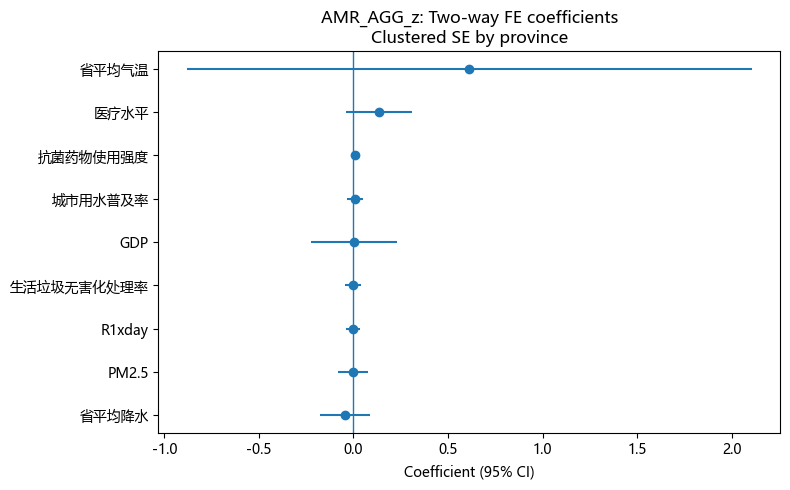

Saved: FE_OUTPUT\AMR_AGG_z_FE_coefplot_both.png


In [16]:
# =========================
# 10) Coefficient plot (merged from former fixed_effects_model.ipynb)
# =========================
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
mpl.rcParams["axes.unicode_minus"] = False

coef = res.params.reindex(X_COLS)
ci_plot = res.conf_int().reindex(X_COLS)
lo = ci_plot.iloc[:, 0]
hi = ci_plot.iloc[:, 1]

plot_df = pd.DataFrame({
    "Predictor": X_COLS,
    "coef": coef.values,
    "lo": lo.values,
    "hi": hi.values,
    "p": res.pvalues.reindex(X_COLS).values,
}).sort_values("coef")

plt.figure(figsize=(8, 5))
ypos = np.arange(len(plot_df))
plt.hlines(y=ypos, xmin=plot_df["lo"], xmax=plot_df["hi"])
plt.plot(plot_df["coef"], ypos, "o")
plt.yticks(ypos, plot_df["Predictor"])
plt.axvline(0, linewidth=1)
plt.title(f"AMR_AGG_z: {MODEL_LABEL} coefficients\nClustered SE by province")
plt.xlabel("Coefficient (95% CI)")
plt.tight_layout()

fig_path = os.path.join(FE_OUT_DIR, f"AMR_AGG_z_FE_coefplot_{MODEL_TAG}.png")
plt.savefig(fig_path, dpi=300)
plt.show()
print("Saved:", fig_path)
